<a href="https://colab.research.google.com/github/s-aleha/Heartdiseasepredictionapp/blob/main/ANN_LAB_NO_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
SALEHA AFZAL
2330-0149
BSAI
ANN LAB NO 3


Features shape: (150, 4)
Target shape: (150,)

----- ReLU Results -----


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hidden Layers: 16 8 | Activation: relu | Accuracy: 1.0
Hidden Layers: 8 4 | Activation: relu | Accuracy: 1.0
Hidden Layers: 32 16 | Activation: relu | Accuracy: 1.0

----- Tanh Results -----
Hidden Layers: 16 8 | Activation: tanh | Accuracy: 1.0
Hidden Layers: 8 4 | Activation: tanh | Accuracy: 0.9666666388511658
Hidden Layers: 32 16 | Activation: tanh | Accuracy: 0.9666666388511658


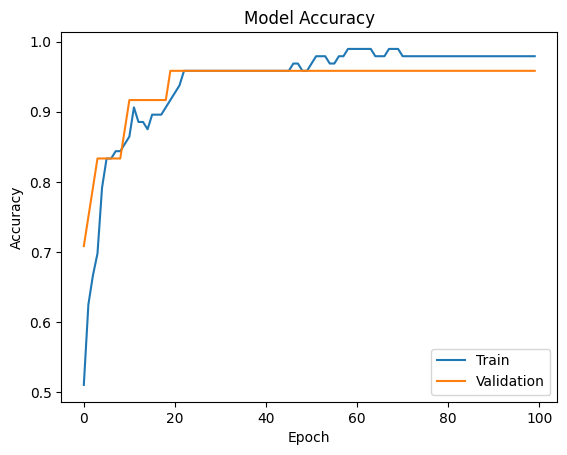

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical


iris = load_iris()
X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


y_encoded = to_categorical(y)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)


def run_model(h1, h2, act):

    model = Sequential()

    model.add(Dense(units=h1, activation=act, input_dim=4))
    model.add(Dense(units=h2, activation=act))
    model.add(Dense(units=3, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=8,
        validation_split=0.2,
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    print("Hidden Layers:", h1, h2, "| Activation:", act, "| Accuracy:", accuracy)

    return history


print("\n ReLU Results ")

history = run_model(16,8,'relu')
run_model(8,4,'relu')
run_model(32,16,'relu')


print("\n Tanh Results")

run_model(16,8,'tanh')
run_model(8,4,'tanh')
run_model(32,16,'tanh')


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()